In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
wrapped_dir = "../phase_data_0_pi/wrapped/"
ground_truth_dir = "../phase_data_0_pi/ground_truth/"

file = 1

print(os.listdir(os.getcwd()))

wrapped = np.load(wrapped_dir + f"{file}.npy")
ground_truth = np.load(ground_truth_dir + f"{file}.npy")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Wrapped Phase")
plt.imshow(wrapped, cmap="gray")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("Ground Truth Unwrapped Phase")
plt.imshow(ground_truth, cmap="gray")
plt.colorbar()
plt.show()


['dataset.py', 'model.py', 'test.ipynb', 'train.py', 'unwrap_generator.py', '__pycache__']


FileNotFoundError: [Errno 2] No such file or directory: '../phase_data_0_pi/wrapped/1.npy'

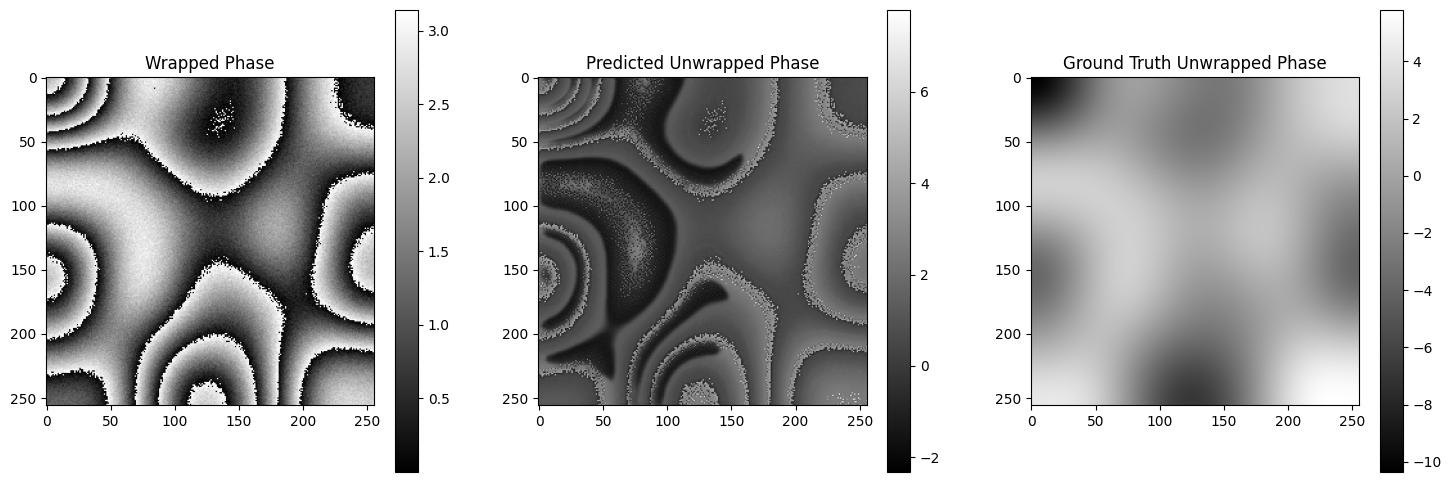

In [ ]:
from model import OrientationUnwrappingNet
import torch

model = OrientationUnwrappingNet()
model.load_state_dict(torch.load("../checkpoints/orientation_unwrapping_net.pth"))
pred = model(torch.from_numpy(wrapped).unsqueeze(0).unsqueeze(0).float())

pred_unwrapped = pred["unwrapped"].squeeze().detach().numpy()
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title("Wrapped Phase")
plt.imshow(wrapped, cmap="gray")
plt.colorbar()
plt.subplot(1, 3, 2)
plt.title("Predicted Unwrapped Phase")
plt.imshow(pred_unwrapped, cmap="gray")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("Ground Truth Unwrapped Phase")
plt.imshow(ground_truth, cmap="gray")
plt.colorbar()

plt.show()

In [3]:
from unwrap_generator import generate_sample
H = 256
W = 256
noisy_input, gt = generate_sample(
    H,
    W,
    noise_level=0.1,
    min_gauss_sigma=30.0,
    max_gauss_sigma=50.0,
    scaling_range=(1.0, 4.5),
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Wrapped Phase with Noise")
plt.imshow(noisy_input, cmap="gray")

plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Ground Truth Unwrapped Phase")
plt.imshow(gt, cmap="gray")
plt.colorbar()
plt.show()

ModuleNotFoundError: No module named 'utils'